In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/sales_branch1.csv")

df["Sales_Amount"] = df["Quantity"] * df["Unit_Price"]

print("Data loaded successfully!")
print(df.shape)

Data loaded successfully!
(50, 14)


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/sales_branch1.csv")

df["Sales_Amount"] = df["Quantity"] * df["Unit_Price"]

print("Data loaded successfully!")
print(df.shape)

Data loaded successfully!
(50, 14)


In [49]:
df["Discount_Amount"] = df["Sales_Amount"] * df["Discount"]

df["Net_Sales"] = df["Sales_Amount"] - df["Discount_Amount"]

print("Total Gross Sales:", df["Sales_Amount"].sum())
print("Total Discount:", df["Discount_Amount"].sum())
print("Total Net Sales:", df["Net_Sales"].sum())

Total Gross Sales: 1978000
Total Discount: 154175.0
Total Net Sales: 1823825.0


In [50]:
branch_sales = df.groupby("Branch")["Sales_Amount"].sum()

print(branch_sales)

Branch
Mumbai    684500
Nashik    531500
Pune      762000
Name: Sales_Amount, dtype: int64


In [51]:
category_sales = df.groupby("Category")["Sales_Amount"].sum()

print(category_sales)

Category
Accessories     267500
Electronics    1226000
Furniture       484500
Name: Sales_Amount, dtype: int64


In [52]:
payment_sales = df.groupby("Payment_Method")["Sales_Amount"].sum()

print(payment_sales)

Payment_Method
Cash           301500
Credit Card    625000
Debit Card     281000
UPI            770500
Name: Sales_Amount, dtype: int64


In [53]:
product_sales = df.groupby("Product_Name")["Sales_Amount"].sum()

print(product_sales.sort_values(ascending=False))

Product_Name
Laptop          440000
Mobile Phone    350000
Printer         220000
Monitor         216000
Office Chair    189000
Desk            168000
Table           127500
Keyboard        112500
Headphones       90000
Mouse            65000
Name: Sales_Amount, dtype: int64


In [54]:
order_status = df["Order_Status"].value_counts()

print(order_status)

Order_Status
Completed    49
Cancelled     1
Name: count, dtype: int64


In [55]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Negative Price:", (df["Unit_Price"] < 0).sum())
print("Zero Price:", (df["Unit_Price"] == 0).sum())

Missing Values: 0
Duplicate Rows: 0
Negative Quantity: 0
Zero Quantity: 0
Negative Price: 0
Zero Price: 0


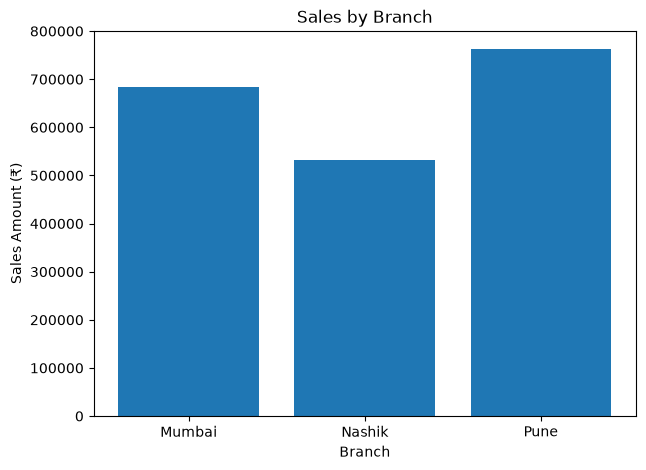

In [56]:
plt.figure(figsize=(7,5))

plt.bar(branch_sales.index, branch_sales.values)

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales Amount (₹)")

plt.show()

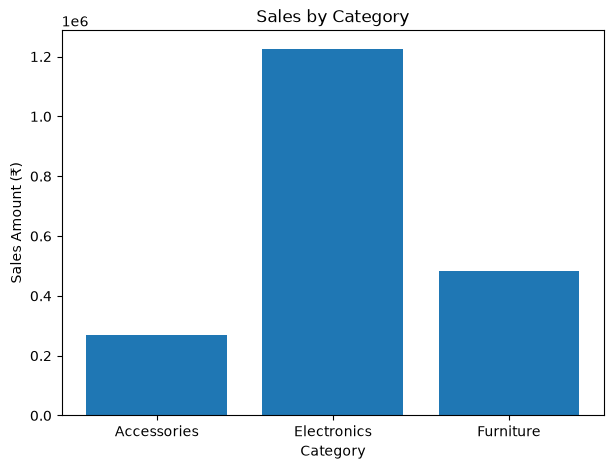

In [57]:
plt.figure(figsize=(7,5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount (₹)")

plt.show()

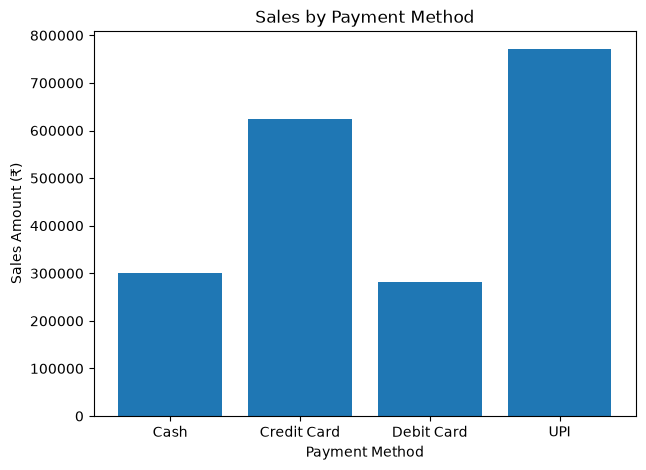

In [58]:
plt.figure(figsize=(7,5))

plt.bar(payment_sales.index, payment_sales.values)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales Amount (₹)")

plt.show()

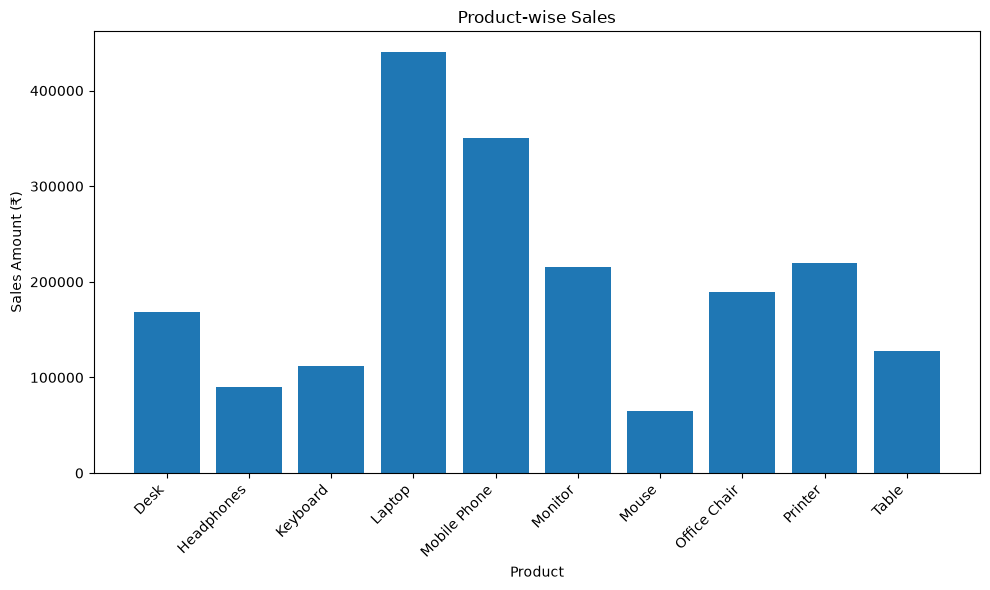

In [59]:
plt.figure(figsize=(10,6))

plt.bar(product_sales.index, product_sales.values)

plt.title("Product-wise Sales")
plt.xlabel("Product")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

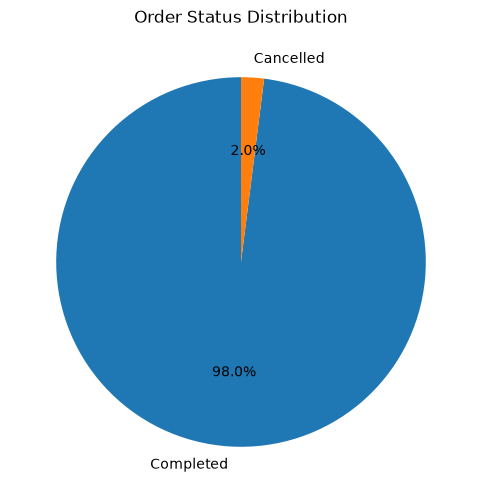

In [60]:
plt.figure(figsize=(6,6))

plt.pie(
    order_status.values,
    labels=order_status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Order Status Distribution")

plt.show()

In [61]:
df.to_csv("../data/processed/processed_sales.csv", index=False)

print("Processed data saved successfully!")

Processed data saved successfully!
